In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from ipywidgets import interact, IntSlider, FloatSlider
%matplotlib ipympl

In [2]:
# Here are all the variables that you could define
leapfrog_steps = 5
step_size = 0.05
repeated_times = 20       

In [3]:
from Robot_Data_Simulator import log_posterior_and_grad

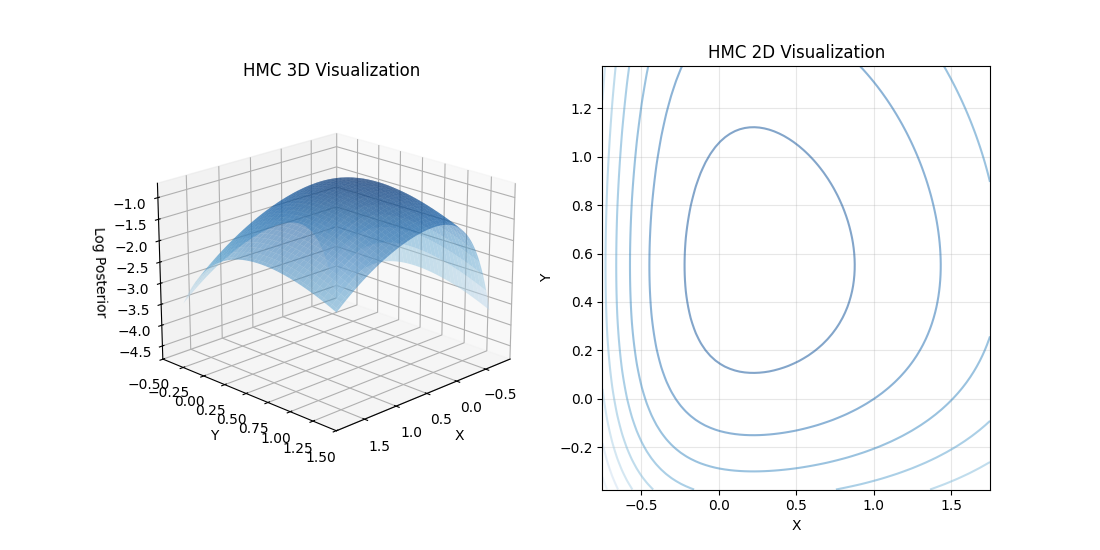

In [4]:
# Initial grid bounds
grid_margin = 0.5  # extra margin beyond sampling points
grid_res_init = 80    # resolution for initial draw
grid_res_redraw = 40  # resolution for dynamic redraws (faster)

def compute_grid(x_min, x_max, y_min, y_max, res=None):
    r = res if res is not None else grid_res_redraw
    x_range = np.linspace(x_min, x_max, r)
    y_range = np.linspace(y_min, y_max, r)
    X, Y = np.meshgrid(x_range, y_range)
    Z = np.vectorize(lambda x, y: log_posterior_and_grad((x,y))[0])(X, Y)
    return X, Y, Z

surface_plot = None
contour_plot = None

def redraw_surface(x_min, x_max, y_min, y_max, res=None):
    global surface_plot, contour_plot
    X, Y, Z = compute_grid(x_min, x_max, y_min, y_max, res=res)
    # 3D
    if surface_plot:
        surface_plot.remove()
    surface_plot = ax.plot_surface(X, Y, Z, cmap='Blues', alpha=0.5, edgecolor='none')
    # 2D
    if contour_plot:
        contour_plot.remove()
    contour_plot = ax2d.contour(X, Y, Z, cmap='Blues', alpha=0.5)

# Initial bounds
x_min, x_max = -0.75, 1.75
y_min, y_max = -0.375, 1.375

fig = plt.figure(figsize=(11, 5.5))
ax = fig.add_subplot(121, projection='3d')
ax.set_xlabel('X', fontsize=10)
ax.set_ylabel('Y', fontsize=10)
ax.set_zlabel('Log Posterior', fontsize=10)
ax.set_title('HMC 3D Visualization', fontsize=12)
ax.view_init(elev=20, azim=45)

ax2d = fig.add_subplot(122)
ax2d.set_xlabel('X', fontsize=10)
ax2d.set_ylabel('Y', fontsize=10)
ax2d.set_title('HMC 2D Visualization', fontsize=12)
ax2d.grid(alpha=0.3)

redraw_surface(x_min, x_max, y_min, y_max, res=grid_res_init)

# F still needed for z-value lookup on trajectory points
F = lambda x, y: log_posterior_and_grad((x, y))[0]

In [5]:
last_q = np.array([0,1])
q_current = None 
p_current = None
path = None
trajectory_line = None
current_point = None
trajectory_line_2d = None
current_point_2d = None
result_text = None 

In [6]:
def reset_hmc():
    global last_q,path,trajectory_line,current_point
    q_current = last_q.copy().astype(np.float64)
    p_current = np.random.randn(2)  # N(0, I), no scaling
    path = [q_current.copy()]
    if trajectory_line:
        trajectory_line.remove()
    if current_point:
        current_point.remove()
    trajectory_line = None
    current_point = None

    fig.canvas.draw()
    fig.canvas.flush_events()

    return q_current, p_current

In [7]:
def check_and_expand_grid(q):
    global x_min, x_max, y_min, y_max
    changed = False
    if q[0] < x_min + grid_margin:
        x_min = q[0] - grid_margin; changed = True
    if q[0] > x_max - grid_margin:
        x_max = q[0] + grid_margin; changed = True
    if q[1] < y_min + grid_margin:
        y_min = q[1] - grid_margin; changed = True
    if q[1] > y_max - grid_margin:
        y_max = q[1] + grid_margin; changed = True
    if changed:
        redraw_surface(x_min, x_max, y_min, y_max)

def update_leapfrog(q, p, path):
    global trajectory_line, current_point, step_size, trajectory_line_2d, current_point_2d

    # Leapfrog: half-step p, full-step q, half-step p
    _, grad = log_posterior_and_grad(q)
    p = p + step_size / 2 * grad
    q = q + step_size * p
    _, grad = log_posterior_and_grad(q)
    p = p + step_size / 2 * grad

    path.append(q.copy())
    check_and_expand_grid(q)

    path_arr = np.array(path)
    z_vals = np.array([F(pt[0], pt[1]) for pt in path_arr])

    if trajectory_line:
        trajectory_line.remove()
    trajectory_line = ax.plot(path_arr[:,0], path_arr[:,1], z_vals,
                              color='#FF4500', marker='o', markersize=8, linewidth=4)[0]
    if current_point:
        current_point.remove()
    current_point = ax.scatter(q[0], q[1], z_vals[-1],
                               color='#FFFF00', s=200, zorder=100, edgecolor='black', linewidth=1)
    if trajectory_line_2d:
        trajectory_line_2d.remove()
    trajectory_line_2d = ax2d.plot(path_arr[:,0], path_arr[:,1],
                                   color='#FF4500', marker='o', markersize=8, linewidth=4)[0]
    if current_point_2d:
        current_point_2d.remove()
    current_point_2d = ax2d.scatter(q[0], q[1],
                                    color='#FFFF00', s=200, zorder=100, edgecolor='black', linewidth=1)
    fig.canvas.draw()
    fig.canvas.flush_events()

    return q, p, path


In [8]:
def run_hmc(leapfrog_steps, step_size):
    global last_q, path, result_text
    q, p = reset_hmc()
    q_initial = q.copy()
    p_initial = p.copy()

    # Run leapfrog steps
    for _ in range(leapfrog_steps):
        q, p, path = update_leapfrog(q, p, path)
        time.sleep(0.1)
        fig.canvas.draw()

    # Metropolis acceptance using log-posterior (consistent with leapfrog)
    log_p_initial, _ = log_posterior_and_grad(q_initial)
    log_p_new, _ = log_posterior_and_grad(q)
    H_initial = -log_p_initial + 0.5 * np.sum(p_initial ** 2)
    H_new = -log_p_new + 0.5 * np.sum(p ** 2)
    accept_prob = min(1.0, np.exp(H_initial - H_new))

    if result_text:
        result_text.remove()
    if np.random.rand() < accept_prob:
        result = f'Accept! P:{accept_prob:.2f}'
        color = 'green'
        last_q = q.copy()
    else:
        result = f'Deny! P:{accept_prob:.2f}'
        color = 'red'
        last_q = q_initial.copy()

    final_point = last_q.copy()
    ax.scatter(final_point[0], final_point[1], F(final_point[0], final_point[1]),
               color=color, s=100, alpha=0.5, zorder=50)
    ax2d.scatter(final_point[0], final_point[1],
                 color=color, s=100, alpha=0.5, zorder=50)
    result_text = ax.text2D(0.05, 0.95, result, transform=ax.transAxes,
                            fontsize=12, color=color,
                            bbox=dict(boxstyle='round', facecolor='white'))
    fig.canvas.draw()

In [ ]:
for _ in range(repeated_times):
    run_hmc(leapfrog_steps,step_size)